In [283]:
import importlib
import plant
importlib.reload (plant)
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 

from plant import DroneConfig, DronePlant, RK4_step, b2w_rotatation, g

In [284]:
def input(t, config):
    gravity = config.mass * g
    thrust = gravity
    torques = np.zeros(3)

    # flly up 
    if 0 <= t < 2:
        thrust = 1.5 * gravity

    # Yaw
    elif 2 <= t < 4:
        thrust = gravity
        torques[2] = 0.004  

    # Pitch
    elif 4 <= t < 6:
        thrust = gravity
        torques[1] = -0.005

    # Roll
    elif 6 <= t < 8:
        thrust = gravity
        torques[0] = 0.002

    return thrust, torques

In [285]:
config = DroneConfig( 
    mass = 2.0,
    inertia=np.diag([0.01, 0.02, 0.03]),
    length = 2.0,
    kd = 0, kt = 0, kb = 0
)

t0 = 0
y0 = np.zeros(12)
times = [t0]
state_vec = [y0.copy()]
t = t0 
y = y0.copy() 
t_end = 10
dt = 1

In [286]:
def f(t, y): 
    thrust, torques = input (t, config)
    plant = DronePlant (config, y) 
    return plant.state_derivatives(thrust, torques)

while t < t_end:
    y = RK4_step(f, t, y, dt)
    t = t + dt
    times.append (t)
    state_vec.append (y.copy())

state_comp = ['x', 'y', 'z', 'vx', 'vy', 'vz', 'phi', 'theta', 'psi', 'wx', 'wy', 'wz']
df = pd.DataFrame(state_vec, columns = state_comp)
df.insert (0, 'time', times)
df

,time,x,y,z,vx,vy,vz,phi,theta,psi,wx,wy,wz
0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1,0.000000,0.000000,-2.452500,0.000000,0.000000,-4.905000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2,0.000000,0.000000,-9.810000,0.000000,0.000000,-8.992500,0.000000,0.000000,0.000000,0.000000,0.000000,0.022222
3,3,0.000000,0.000000,-18.802500,0.000000,0.000000,-8.992500,0.000000,0.000000,0.088889,0.000000,0.000000,0.155556
4,4,0.000000,0.000000,-27.795000,0.000000,0.000000,-8.992500,0.000000,0.000000,0.311111,0.000000,-0.041667,0.266667
5,5,0.153621,0.073161,-36.781471,0.533350,0.293968,-8.957987,-0.000121,-0.165429,0.578988,0.044182,-0.287220,0.267882
6,6,1.732971,1.226094,-45.529912,2.971977,2.529168,-8.306238,-0.008200,-0.566897,0.872997,0.187368,-0.469905,0.281092
7,7,6.396439,6.465600,-52.601722,6.079435,8.619182,-5.355791,0.031180,-0.995403,1.309691,0.515777,-0.361757,0.330136
8,8,12.459191,19.403873,-55.241584,4.993353,17.258699,0.399183,-0.116639,-1.240157,2.201989,0.772275,-0.120603,0.384403
9,9,14.247343,39.894346,-51.522067,-2.068806,22.713126,6.803620,-0.321240,-1.111387,3.249686,0.760718,0.179513,0.376631


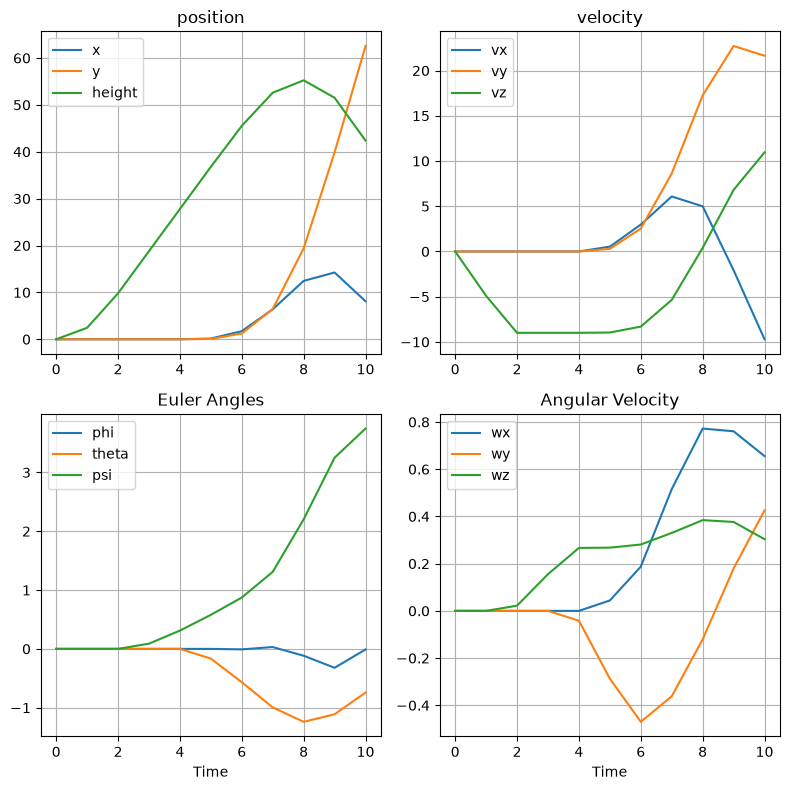

In [287]:
height = -df['z']
fig, axs = plt.subplots (2, 2, figsize = (8, 8))

axs[0, 0].plot (df['time'], df['x'], label = 'x')
axs[0, 0].plot (df['time'], df['y'], label = 'y')
axs[0, 0].plot (df['time'], height, label = 'height')
axs[0, 0].set_title ('position') 
axs[0, 0].legend() 
axs[0, 0].grid (True)

axs[0, 1].plot (df['time'], df['vx'], label = 'vx')
axs[0, 1].plot (df['time'], df['vy'], label = 'vy')
axs[0, 1].plot (df['time'], df['vz'], label = 'vz')
axs[0, 1].set_title ('velocity')
axs[0, 1].legend() 
axs[0, 1].grid(True)

axs[1, 0].plot (df['time'], (df['phi']), label = 'phi')
axs[1, 0].plot (df['time'], (df['theta']), label = 'theta')
axs[1, 0].plot (df['time'], (df['psi']), label = 'psi')
axs[1, 0].set_title ('Euler Angles')
axs[1, 0].legend()
axs[1, 0].grid (True) 

axs[1, 1].plot (df['time'], df['wx'], label = 'wx')
axs[1, 1].plot (df['time'], df['wy'], label = 'wy')
axs[1, 1].plot (df['time'], df['wz'], label = 'wz')
axs[1, 1].set_title ('Angular Velocity')
axs[1, 1].legend()
axs[1, 1].grid (True) 

axs[1, 0].set_xlabel('Time')
axs[1, 1].set_xlabel('Time')

plt.tight_layout()
plt.show() 

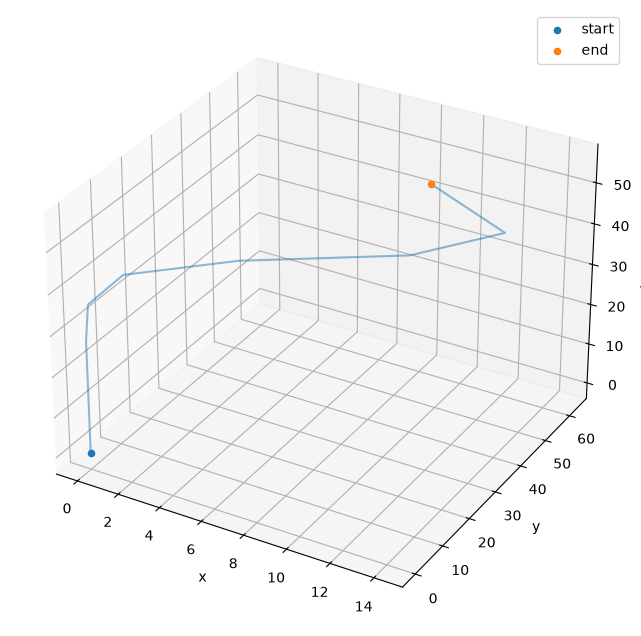

In [288]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection = '3d')
height = -df['z']
ax.plot (df['x'], df['y'], height, alpha = 0.5)
ax.scatter (
    df['x'].iloc[0], 
    df['y'].iloc[0], 
    height.iloc[0],
    label = 'start', 
)
ax.scatter (
    df['x'].iloc[-1],
    df['y'].iloc[-1],
    height.iloc[-1],
    label = 'end'
)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('height')
ax.legend()

plt.show() 

Overview:
* wx changes first, while phi changes very trivially
* z gets more negative, meaning drone is flying up

Conclusion:
* The drone behaves as expected, everythign looks kinda correct